# Travel Aggregator Analysis - MyNextBooking
**Certification Project | Data Science & ML Program**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

## Load Data

In [6]:
bookings = pd.read_csv('Dataset/Datasets/Bookings.csv')
sessions = pd.read_csv('Dataset/Datasets/Sessions.csv')

bookings['booking_time'] = pd.to_datetime(bookings['booking_time'], format='ISO8601', utc=True)
sessions['search_time'] = pd.to_datetime(sessions['search_time'], format='ISO8601', utc=True)
sessions['session_starting_time'] = pd.to_datetime(sessions['session_starting_time'], format='ISO8601', utc=True)

print('Bookings shape:', bookings.shape)
print('Sessions shape:', sessions.shape)
bookings.head()

Bookings shape: (339, 13)
Sessions shape: (1497, 5)


,customer_id,booking_id,from_city,from_country,to_city,to_country,booking_time,device_type_used,INR_Amount,service_name,no_of_passengers,days_to_departure,distance_km
0,customer_259,booking_82,Gurgaon,India,Ahmedabad,India,2020-02-05 16:12:08+00:00,Desktop,2565.28,MMT,1.0,10.0,747.8
1,customer_303,booking_156,Delhi,India,Brussels,Belgium,2018-11-21 08:21:47+00:00,Android,23120.00,YATRA,1.0,1.0,6701.5
2,customer_203,booking_99,Devanhalli,India,Frankfurt am Main,Germany,2019-12-16 22:54:58+00:00,Android,25717.60,YATRA,1.0,32.0,7712.0
3,customer_211,booking_319,Gurgaon,India,Frankfurt am Main,Germany,2021-10-29 12:25:38+00:00,Desktop,135969.60,GOIBIBO,2.0,69.0,6112.5
4,customer_287,booking_222,Gurgaon,India,Roissy-en-France,France,2020-08-11 16:09:10+00:00,Android,31791.20,GOIBIBO,1.0,3.0,6570.4


In [7]:
sessions.head()

,session_id,search_id,search_time,session_starting_time,booking_id
0,session_322,search_784,2020-01-21 21:35:38.910000+00:00,2020-01-21 21:10:12+00:00,NaN
1,session_322,search_776,2020-01-21 21:37:37.697000+00:00,2020-01-21 21:10:12+00:00,NaN
2,session_322,search_623,2020-01-21 21:36:11.392000+00:00,2020-01-21 21:10:12+00:00,NaN
3,session_322,search_270,2020-01-21 21:16:07.685000+00:00,2020-01-21 21:10:12+00:00,NaN
4,session_322,search_905,2020-01-21 21:34:55.673000+00:00,2020-01-21 21:10:12+00:00,NaN


## Q1 - Distinct Bookings, Sessions and Searches

In [8]:
distinct_bookings = bookings['booking_id'].nunique()
distinct_sessions = sessions['session_id'].nunique()
distinct_searches = sessions['search_id'].nunique()

print(f'Distinct Bookings : {distinct_bookings}')
print(f'Distinct Sessions : {distinct_sessions}')
print(f'Distinct Searches : {distinct_searches}')

Distinct Bookings : 339
Distinct Sessions : 331
Distinct Searches : 1360


## Q2 - Sessions with More than One Booking

In [9]:
bookings_per_session = (
    sessions.dropna(subset=['booking_id'])
    .groupby('session_id')['booking_id']
    .nunique()
)

sessions_with_multiple_bookings = (bookings_per_session > 1).sum()
print(f'Sessions with more than one booking: {sessions_with_multiple_bookings}')

print('\nBookings-per-session distribution:')
print(bookings_per_session.value_counts().sort_index())

Sessions with more than one booking: 10

Bookings-per-session distribution:
booking_id
1    319
2     10
Name: count, dtype: int64


## Q3 - Highest Bookings by Day of Week + Pie Chart

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

bookings['day_of_week'] = bookings['booking_time'].dt.day_name()
bookings_by_day = bookings['day_of_week'].value_counts().reindex(day_order)

print('Number of bookings by day of week:')
print(bookings_by_day.to_string())
print(f"\nHighest booking day: {bookings_by_day.idxmax()} ({bookings_by_day.max()} bookings)")

Number of bookings by day of week:
day_of_week
Monday       51
Tuesday      59
Wednesday    34
Thursday     65
Friday       51
Saturday     44
Sunday       35

Highest booking day: Thursday (65 bookings)


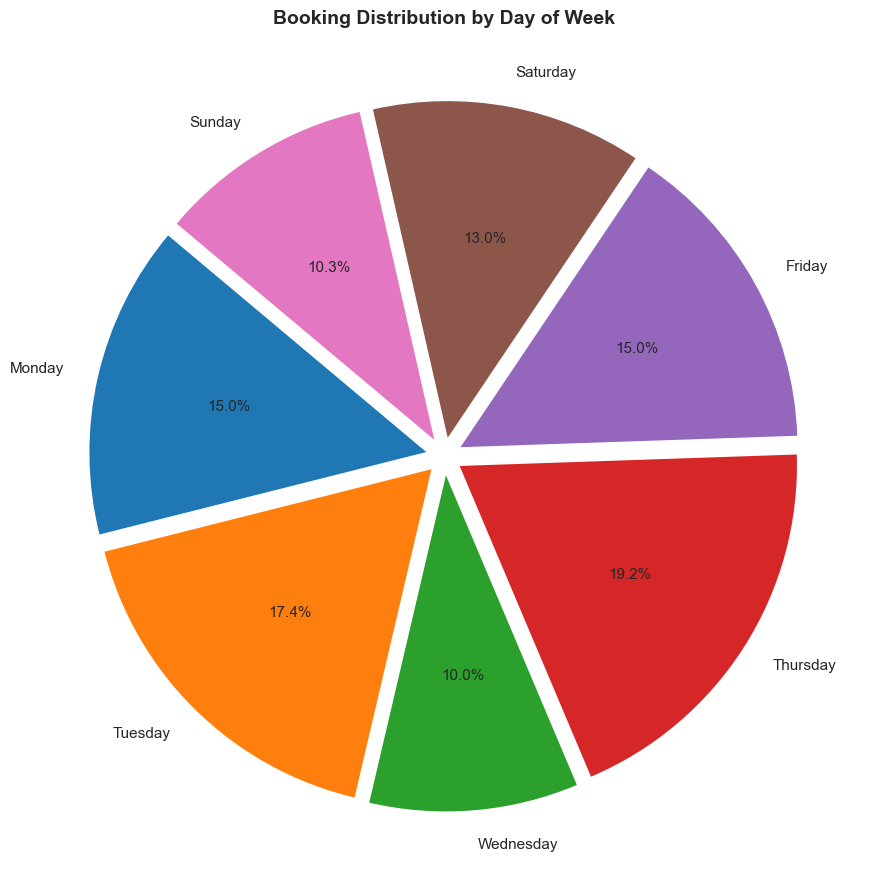

In [11]:
colors = plt.cm.tab10.colors[:7]

fig, ax = plt.subplots(figsize=(9, 9))
ax.pie(
    bookings_by_day,
    labels=bookings_by_day.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.05] * 7,
    startangle=140,
    textprops={'fontsize': 11}
)
ax.set_title('Booking Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('q3_booking_by_day_pie.png', dpi=150)
plt.show()

## Q4 - Total Bookings and Gross Booking Value per Service

In [12]:
service_summary = (
    bookings.groupby('service_name')
    .agg(
        Total_Bookings=('booking_id', 'count'),
        Total_GBV_INR=('INR_Amount', 'sum')
    )
    .reset_index()
    .sort_values('Total_Bookings', ascending=False)
)
service_summary['Total_GBV_INR'] = service_summary['Total_GBV_INR'].round(2)
print(service_summary.to_string(index=False))

service_name  Total_Bookings  Total_GBV_INR
     GOIBIBO             186     5897637.97
       YATRA             105     3378702.13
         MMT              48      665669.08


## Q5 - Most Booked Route for Customers with More than 1 Booking

In [13]:
multi_booking_customers = (
    bookings.groupby('customer_id')['booking_id']
    .count()
    .loc[lambda x: x > 1]
    .index
)

multi_bookings = bookings[bookings['customer_id'].isin(multi_booking_customers)].copy()
multi_bookings['route'] = multi_bookings['from_city'] + ' → ' + multi_bookings['to_city']

top_route = multi_bookings['route'].value_counts()

print(f'Customers with >1 booking: {len(multi_booking_customers)}')
print(f'\nTop 10 most booked routes:')
print(top_route.head(10).to_string())
print(f'\nMost booked route: {top_route.idxmax()} ({top_route.max()} bookings)')

Customers with >1 booking: 26

Top 10 most booked routes:
route
Gurgaon → Roissy-en-France    5
Gurgaon → Rāja Sānsi          3
Gurgaon → Tiruchi             2
Gurgaon → Bhubaneswar         2
Bālāpur → Düsseldorf          2
Gurgaon → Bagdogra            2
Durlaga → Bhubaneswar         2
Gurgaon → Paris               2
Devanhalli → Gurgaon          2
Kolkata → Gurgaon             1

Most booked route: Gurgaon → Roissy-en-France (5 bookings)


## Q6 - Top 3 Departure Cities Where Customers Book Most in Advance
*(min 5 departures)*

In [14]:
city_advance = (
    bookings.groupby('from_city')['days_to_departure']
    .agg(avg_days_to_departure='mean', num_departures='count')
    .reset_index()
)

top3_advance = (
    city_advance[city_advance['num_departures'] >= 5]
    .sort_values('avg_days_to_departure', ascending=False)
    .head(3)
    .reset_index(drop=True)
)
top3_advance.index += 1
top3_advance['avg_days_to_departure'] = top3_advance['avg_days_to_departure'].round(2)
print('Top 3 departure cities with the most advance bookings:')
print(top3_advance.to_string())

Top 3 departure cities with the most advance bookings:
    from_city  avg_days_to_departure  num_departures
1     Bālāpur                  46.17               6
2  Devanhalli                  29.58              24
3     Chennai                  26.19              16


## Q7 - Correlation Heatmap of Numerical Columns

Numerical columns: ['INR_Amount', 'no_of_passengers', 'days_to_departure', 'distance_km']


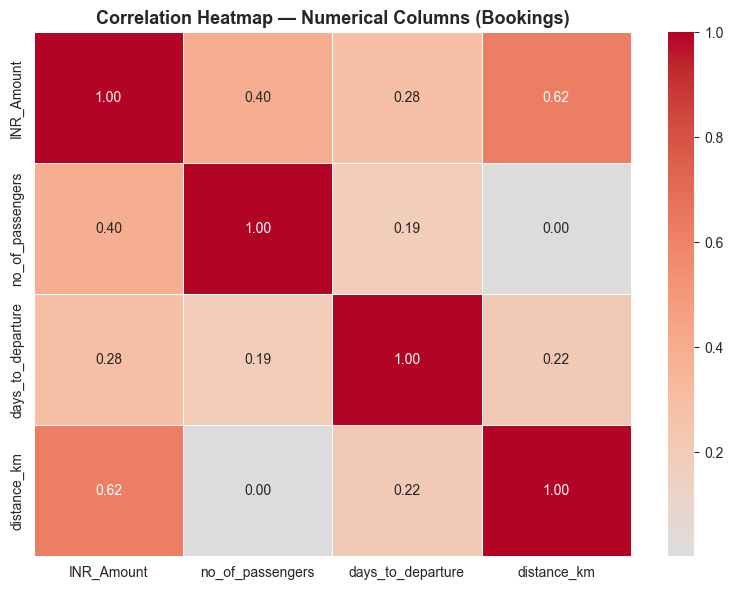


Pair with maximum correlation: INR_Amount & distance_km (r = 0.6236)


In [15]:
num_cols = bookings.select_dtypes(include=[np.number]).columns.tolist()
print('Numerical columns:', num_cols)

corr_matrix = bookings[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)
ax.set_title('Correlation Heatmap — Numerical Columns (Bookings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q7_correlation_heatmap.png', dpi=150)
plt.show()

# Max off-diagonal correlation
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
max_corr_pair = corr_upper.stack().idxmax()
max_corr_val = corr_upper.stack().max()
print(f'\nPair with maximum correlation: {max_corr_pair[0]} & {max_corr_pair[1]} (r = {max_corr_val:.4f})')

## Q8 - Most Used Device Type per Service

In [16]:
device_by_service = (
    bookings.groupby(['service_name', 'device_type_used'])['booking_id']
    .count()
    .reset_index(name='booking_count')
)

most_used_device = (
    device_by_service
    .sort_values('booking_count', ascending=False)
    .groupby('service_name')
    .first()
    .reset_index()
    .rename(columns={'device_type_used': 'most_used_device', 'booking_count': 'bookings'})
)
print('Most used device type per service:')
print(most_used_device.to_string(index=False))

print('\nFull pivot (service × device):')
pivot = device_by_service.pivot(
    index='service_name', columns='device_type_used', values='booking_count'
).fillna(0).astype(int)
print(pivot)

Most used device type per service:
service_name most_used_device  bookings
     GOIBIBO              IOS        70
         MMT          Desktop        30
       YATRA          Desktop        51

Full pivot (service × device):
device_type_used  Android  Desktop  IOS  MobileWeb  Tablet
service_name                                              
GOIBIBO                44       61   70         11       0
MMT                     8       30    5          5       0
YATRA                  18       51   22         11       3


## Q9 - Quarterly Booking Trends by Device Type

In [17]:
bookings['year_quarter'] = bookings['booking_time'].dt.to_period('Q')

quarterly_device = (
    bookings.groupby(['year_quarter', 'device_type_used'])['booking_id']
    .count()
    .reset_index(name='bookings')
)

pivot_quarterly = quarterly_device.pivot(
    index='year_quarter', columns='device_type_used', values='bookings'
).fillna(0)

print(pivot_quarterly)

device_type_used  Android  Desktop   IOS  MobileWeb  Tablet
year_quarter                                               
2018Q3                3.0      6.0   0.0        2.0     1.0
2018Q4                3.0     22.0   4.0        4.0     1.0
2019Q1                0.0      1.0   0.0        0.0     0.0
2019Q2                0.0      1.0   0.0        0.0     1.0
2019Q3                3.0      7.0   4.0        0.0     0.0
2019Q4               14.0     15.0  14.0        0.0     0.0
2020Q1               19.0     29.0  25.0       10.0     0.0
2020Q2                2.0      0.0   0.0        0.0     0.0
2020Q3                3.0      0.0   4.0        0.0     0.0
2020Q4                6.0     12.0   2.0        1.0     0.0
2021Q1                0.0     11.0   5.0        1.0     0.0
2021Q2                2.0     10.0   3.0        0.0     0.0
2021Q3                5.0      6.0   5.0        2.0     0.0
2021Q4                6.0     10.0  14.0        4.0     0.0
2022Q1                2.0      8.0  10.0

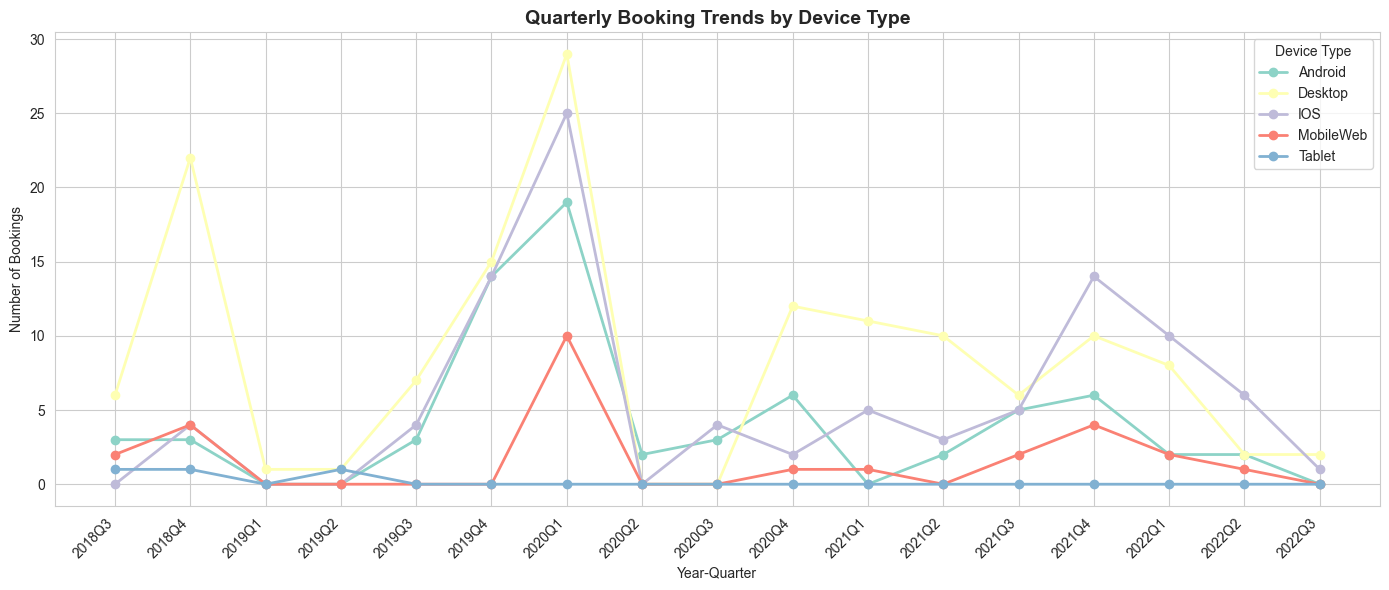

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

for device in pivot_quarterly.columns:
    ax.plot(
        pivot_quarterly.index.astype(str),
        pivot_quarterly[device],
        marker='o',
        linewidth=2,
        label=device
    )

ax.set_title('Quarterly Booking Trends by Device Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Year-Quarter')
ax.set_ylabel('Number of Bookings')
ax.legend(title='Device Type')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('q9_quarterly_device_trends.png', dpi=150)
plt.show()

## Q10 - Overall Booking-to-Search Ratio (oBSR)

oBSR = total bookings / total searches. A search row counts as a booking if its `booking_id` is not null.

In [19]:
sessions_df = sessions.copy()
sessions_df['date'] = pd.to_datetime(sessions_df['search_time'].dt.date)
sessions_df['month'] = sessions_df['search_time'].dt.month
sessions_df['month_name'] = sessions_df['search_time'].dt.strftime('%B')
sessions_df['day_of_week'] = sessions_df['search_time'].dt.day_name()
sessions_df['has_booking'] = sessions_df['booking_id'].notna().astype(int)

print('Sessions sample with booking flag:')
print(sessions_df[['session_id','search_id','search_time','booking_id','has_booking']].head(10))

Sessions sample with booking flag:
    session_id    search_id                      search_time   booking_id  \
0  session_322   search_784 2020-01-21 21:35:38.910000+00:00          NaN   
1  session_322   search_776 2020-01-21 21:37:37.697000+00:00          NaN   
2  session_322   search_623 2020-01-21 21:36:11.392000+00:00          NaN   
3  session_322   search_270 2020-01-21 21:16:07.685000+00:00          NaN   
4  session_322   search_905 2020-01-21 21:34:55.673000+00:00          NaN   
5  session_322   search_506 2020-01-21 21:10:58.482000+00:00   booking_54   
6  session_283   search_880 2020-01-21 05:33:48.061000+00:00  booking_106   
7  session_194   search_312 2019-09-05 09:04:40.423000+00:00    booking_1   
8   session_52  search_1227 2020-01-20 16:54:07.232000+00:00          NaN   
9   session_52  search_1110 2020-01-20 17:03:52.145000+00:00  booking_282   

   has_booking  
0            0  
1            0  
2            0  
3            0  
4            0  
5            1 

In [20]:
# Average oBSR per month
monthly_obsr = (
    sessions_df.groupby(['month', 'month_name'])
    .apply(lambda g: g['has_booking'].sum() / len(g))
    .reset_index(name='oBSR')
    .sort_values('month')
)

print('Average oBSR by Month:')
print(monthly_obsr[['month_name', 'oBSR']].to_string(index=False))

Average oBSR by Month:
month_name     oBSR
   January 0.260664
  February 0.293785
     March 0.257143
     April 0.275000
       May 0.181818
      June 0.393939
      July 0.162500
    August 0.300000
 September 0.384615
   October 0.170347
  November 0.226519
  December 0.251256


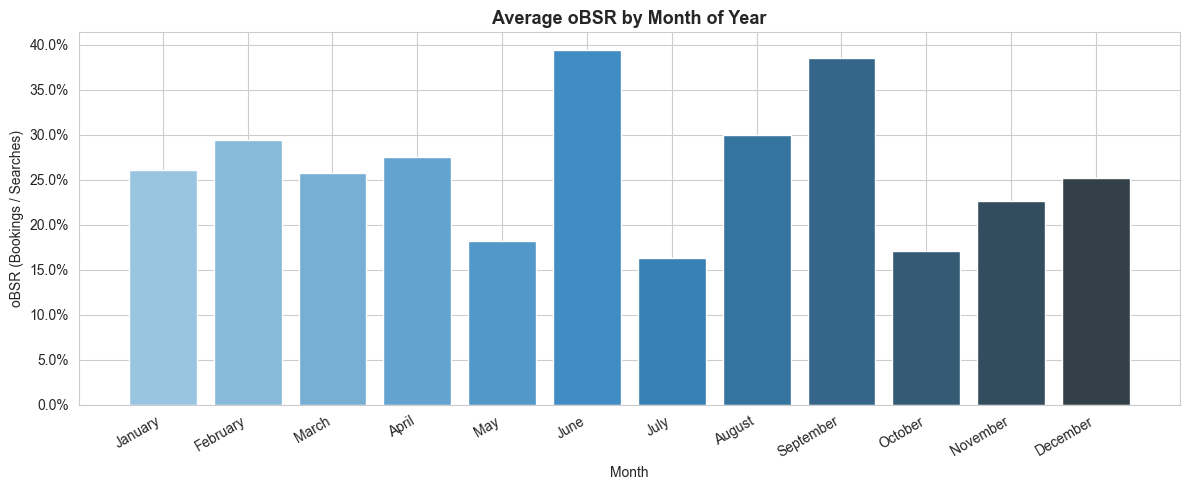

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_obsr['month_name'], monthly_obsr['oBSR'],
       color=sns.color_palette('Blues_d', 12))
ax.set_title('Average oBSR by Month of Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('oBSR (Bookings / Searches)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('q10_obsr_by_month.png', dpi=150)
plt.show()

In [22]:
# Average oBSR per day of week
day_order_week = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily_obsr = (
    sessions_df.groupby('day_of_week')
    .apply(lambda g: g['has_booking'].sum() / len(g))
    .reindex(day_order_week)
    .reset_index(name='oBSR')
)

print('Average oBSR by Day of Week:')
print(daily_obsr.to_string(index=False))

Average oBSR by Day of Week:
day_of_week     oBSR
     Monday 0.212598
    Tuesday 0.284404
  Wednesday 0.165899
   Thursday 0.239726
     Friday 0.280788
   Saturday 0.245000
     Sunday 0.336283


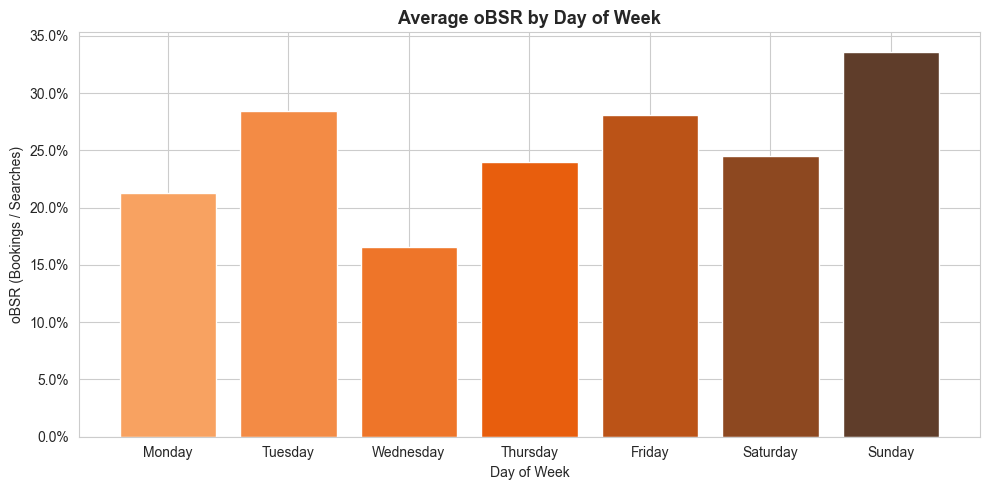

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(daily_obsr['day_of_week'], daily_obsr['oBSR'],
       color=sns.color_palette('Oranges_d', 7))
ax.set_title('Average oBSR by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('oBSR (Bookings / Searches)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.savefig('q10_obsr_by_day.png', dpi=150)
plt.show()

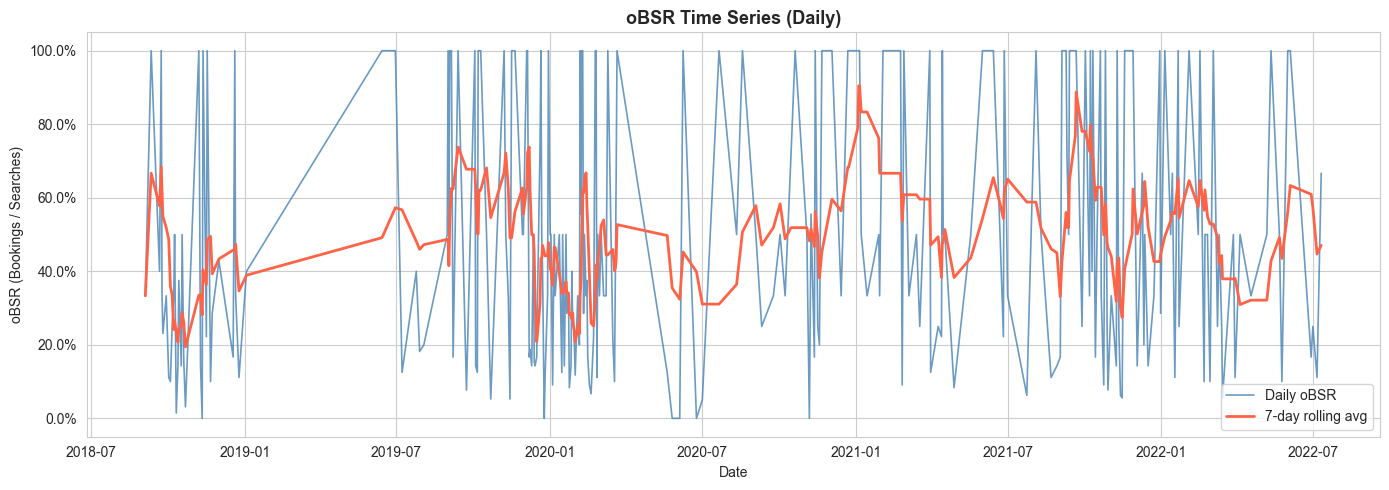

In [24]:
# oBSR daily time series
daily_ts = (
    sessions_df.groupby('date')
    .apply(lambda g: g['has_booking'].sum() / len(g))
    .reset_index(name='oBSR')
    .sort_values('date')
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_ts['date'], daily_ts['oBSR'],
        linewidth=1.2, color='steelblue', alpha=0.8, label='Daily oBSR')

rolling_avg = daily_ts.set_index('date')['oBSR'].rolling(window=7, min_periods=1).mean()
ax.plot(rolling_avg.index, rolling_avg.values,
        linewidth=2, color='tomato', label='7-day rolling avg')

ax.set_title('oBSR Time Series (Daily)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('oBSR (Bookings / Searches)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.legend()
plt.tight_layout()
plt.savefig('q10_obsr_time_series.png', dpi=150)
plt.show()

## Summary

- **Q1:** 339 bookings, 331 sessions, 1360 unique searches
- **Q2:** 10 sessions had more than one booking
- **Q3:** Thursday had the most bookings (65)
- **Q4:** GOIBIBO leads with 186 bookings and ₹58.97L in GBV
- **Q5:** Most booked route among repeat customers — Gurgaon to Roissy-en-France (5 bookings)
- **Q6:** Top advance-booking cities — Bālāpur (46.2 days avg), Devanhalli (29.6), Chennai (26.2)
- **Q7:** Strongest correlation — INR_Amount and distance_km (r = 0.62)
- **Q8:** GOIBIBO users mostly used IOS, MMT and YATRA mostly used Desktop
- **Q9:** Desktop and IOS were dominant across quarters, with a clear spike in 2020 Q1
- **Q10:** June had the highest oBSR (39.4%), July the lowest (16.3%); Sunday was the best day (33.6%)